<a href="https://colab.research.google.com/github/amii-uwl-dba/northstar-analytics/blob/main/01_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/northstar_dataset.zip'
extract_path = '/content/northstar_dataset/'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted successfully")

Extracted successfully


In [4]:
import pandas as pd

path = '/content/northstar_dataset/northstar_dataset/'

customers  = pd.read_csv(path + 'customers.csv')
orders     = pd.read_csv(path + 'orders.csv')
deliveries = pd.read_csv(path + 'deliveries.csv')
drivers    = pd.read_csv(path + 'drivers.csv')
vehicles   = pd.read_csv(path + 'vehicles.csv')
complaints = pd.read_csv(path + 'complaints.csv')
incidents  = pd.read_csv(path + 'incidents.csv')
app_events = pd.read_csv(path + 'app_events.csv')
hubs       = pd.read_csv(path + 'hubs.csv')

print("All files loaded successfully")

All files loaded successfully


In [5]:
for name, df in [('customers', customers), ('orders', orders),
                 ('deliveries', deliveries), ('drivers', drivers),
                 ('vehicles', vehicles), ('complaints', complaints),
                 ('incidents', incidents), ('app_events', app_events),
                 ('hubs', hubs)]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

customers: 650 rows, 9 columns
orders: 1250 rows, 11 columns
deliveries: 950 rows, 13 columns
drivers: 170 rows, 8 columns
vehicles: 120 rows, 8 columns
complaints: 320 rows, 10 columns
incidents: 280 rows, 7 columns
app_events: 640 rows, 10 columns
hubs: 8 rows, 5 columns


In [6]:
for name, df in [('customers', customers), ('orders', orders),
                 ('deliveries', deliveries), ('drivers', drivers),
                 ('vehicles', vehicles), ('complaints', complaints),
                 ('incidents', incidents), ('app_events', app_events),
                 ('hubs', hubs)]:
    print(f"\n=== {name} ===")
    print("Missing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])


=== customers ===
Missing values:
loyalty_score        20
preferred_channel    13
dtype: int64

=== orders ===
Missing values:
booking_channel    25
dtype: int64

=== deliveries ===
Missing values:
delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64

=== drivers ===
Missing values:
training_score    7
dtype: int64

=== vehicles ===
Missing values:
battery_health_pct    4
dtype: int64

=== complaints ===
Missing values:
compensation_amount    16
dtype: int64

=== incidents ===
Missing values:
resolved_hours    17
dtype: int64

=== app_events ===
Missing values:
order_id    144
dtype: int64

=== hubs ===
Missing values:
Series([], dtype: int64)


In [7]:
# Standardise zone names to Title Case across all files
customers['home_zone']        = customers['home_zone'].str.strip().str.title()
orders['pickup_zone']         = orders['pickup_zone'].str.strip().str.title()
orders['dropoff_zone']        = orders['dropoff_zone'].str.strip().str.title()
drivers['base_zone']          = drivers['base_zone'].str.strip().str.title()
vehicles['assigned_zone']     = vehicles['assigned_zone'].str.strip().str.title()
app_events['zone_context']    = app_events['zone_context'].str.strip().str.title()
hubs['zone']                  = hubs['zone'].str.strip().str.title()

print("Zone names standardised successfully")

Zone names standardised successfully


In [8]:
# Fill missing values in each file
customers['loyalty_score']     = customers['loyalty_score'].fillna(customers['loyalty_score'].median())
customers['preferred_channel'] = customers['preferred_channel'].fillna('Unknown')

orders['booking_channel']      = orders['booking_channel'].fillna('Unknown')

deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(deliveries['customer_rating_post_delivery'].median())
deliveries['delivery_completed_at']         = deliveries['delivery_completed_at'].fillna('Unknown')

drivers['training_score']      = drivers['training_score'].fillna(drivers['training_score'].median())

vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median())

complaints['compensation_amount'] = complaints['compensation_amount'].fillna(complaints['compensation_amount'].median())

incidents['resolved_hours']    = incidents['resolved_hours'].fillna(incidents['resolved_hours'].median())

app_events['order_id']         = app_events['order_id'].fillna('No Order')

print("Missing values fixed successfully")

Missing values fixed successfully


In [9]:
import pandas as pd

customers['signup_date']               = pd.to_datetime(customers['signup_date'], errors='coerce')
orders['order_created_at']             = pd.to_datetime(orders['order_created_at'], errors='coerce')
deliveries['dispatch_time']            = pd.to_datetime(deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at']    = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
complaints['created_at']               = pd.to_datetime(complaints['created_at'], errors='coerce')
incidents['reported_at']               = pd.to_datetime(incidents['reported_at'], errors='coerce')
app_events['event_timestamp']          = pd.to_datetime(app_events['event_timestamp'], errors='coerce')

print("Timestamps parsed successfully")

Timestamps parsed successfully


In [21]:
# Calculate actual delivery duration in hours
deliveries['actual_duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# Merge with orders to get promised window
deliveries = deliveries.merge(
    orders[['order_id', 'promised_window_hours']], on='order_id', how='left'
)

# Calculate delay and late flag
deliveries['delay_hrs'] = deliveries['actual_duration_hrs'] - deliveries['promised_window_hours']
deliveries['is_late']   = (deliveries['delay_hrs'] > 0).astype(int)

# Failed delivery flag
deliveries['failed_flag'] = (deliveries['delivery_status'] == 'Failed').astype(int)

# Cost per km
deliveries['cost_per_km'] = deliveries['fuel_or_charge_cost'] / deliveries['route_distance_km']

print("Features created successfully")
print(deliveries[['delivery_id','actual_duration_hrs','delay_hrs','is_late','failed_flag','cost_per_km']].head())

Features created successfully
  delivery_id  actual_duration_hrs  delay_hrs  is_late  failed_flag  \
0     DL00001            22.149973  16.149973        1            1   
1     DL00002            -1.100000  -3.100000        0            0   
2     DL00003             1.108991  -0.891009        0            0   
3     DL00004            23.985584  -0.014416        0            0   
4     DL00005             4.042814  -1.957186        0            0   

   cost_per_km  
0     0.698146  
1     1.296905  
2     1.074495  
3     0.829476  
4     0.634986  


In [22]:
import os
os.makedirs('/content/drive/MyDrive/northstar_dataset', exist_ok=True)
print("Folder created")

Folder created


In [23]:
deliveries.to_csv('/content/drive/MyDrive/northstar_dataset/clean_deliveries.csv', index=False)
orders.to_csv('/content/drive/MyDrive/northstar_dataset/clean_orders.csv', index=False)
customers.to_csv('/content/drive/MyDrive/northstar_dataset/clean_customers.csv', index=False)
complaints.to_csv('/content/drive/MyDrive/northstar_dataset/clean_complaints.csv', index=False)
drivers.to_csv('/content/drive/MyDrive/northstar_dataset/clean_drivers.csv', index=False)
vehicles.to_csv('/content/drive/MyDrive/northstar_dataset/clean_vehicles.csv', index=False)
incidents.to_csv('/content/drive/MyDrive/northstar_dataset/clean_incidents.csv', index=False)
app_events.to_csv('/content/drive/MyDrive/northstar_dataset/clean_app_events.csv', index=False)
hubs.to_csv('/content/drive/MyDrive/northstar_dataset/clean_hubs.csv', index=False)

print("All cleaned files saved to Drive successfully")

All cleaned files saved to Drive successfully


In [24]:
import os

files = os.listdir('/content/drive/MyDrive/northstar_dataset')
print("Files in Drive folder:")
for f in files:
    print(f)

Files in Drive folder:
clean_deliveries.csv
clean_orders.csv
clean_customers.csv
clean_complaints.csv
clean_drivers.csv
clean_vehicles.csv
clean_incidents.csv
clean_app_events.csv
clean_hubs.csv


Section 2 — Python Analytics

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Libraries loaded")

Libraries loaded


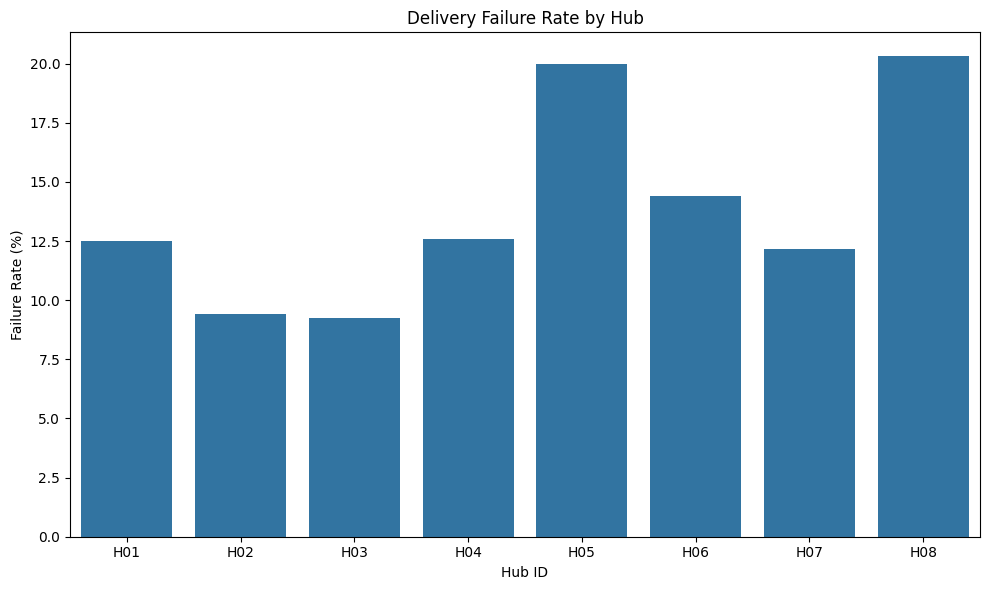

  hub_id  failure_rate
0    H01     12.500000
1    H02      9.433962
2    H03      9.243697
3    H04     12.598425
4    H05     20.000000
5    H06     14.423077
6    H07     12.173913
7    H08     20.312500


In [26]:
# Failure rate by hub
hub_failures = deliveries.groupby('hub_id')['failed_flag'].mean() * 100
hub_failures = hub_failures.reset_index()
hub_failures.columns = ['hub_id', 'failure_rate']

plt.figure(figsize=(10,6))
sns.barplot(data=hub_failures, x='hub_id', y='failure_rate')
plt.title('Delivery Failure Rate by Hub')
plt.xlabel('Hub ID')
plt.ylabel('Failure Rate (%)')
plt.tight_layout()
plt.show()

print(hub_failures)

H05 and H08 show the highest delivery failure rates at 20%,
compared to H02 and H03 which perform best at around 9%.
This suggests certain hubs have operational problems that
need investigation.

explanation for wht this code does
It answers the business question:

"Which hubs have the most delivery failures?"


Groups all deliveries by hub
Calculates what percentage of deliveries failed at each hub
Shows it as a bar chart so you can easily compare hubs

This directly links to NorthStar's problem of some city zones performing worse than others.

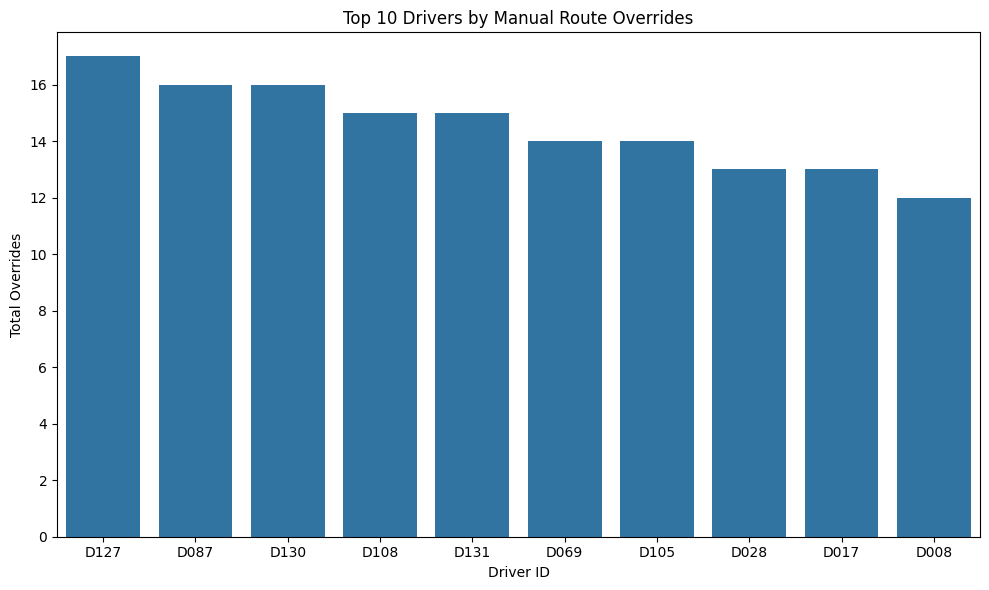

    driver_id  total_overrides
126      D127               17
86       D087               16
129      D130               16
107      D108               15
130      D131               15
68       D069               14
104      D105               14
27       D028               13
16       D017               13
7        D008               12


In [27]:
# Manual overrides by driver
driver_overrides = deliveries.groupby('driver_id')['manual_route_override_count'].sum()
driver_overrides = driver_overrides.reset_index()
driver_overrides.columns = ['driver_id', 'total_overrides']
driver_overrides = driver_overrides.sort_values('total_overrides', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=driver_overrides, x='driver_id', y='total_overrides')
plt.title('Top 10 Drivers by Manual Route Overrides')
plt.xlabel('Driver ID')
plt.ylabel('Total Overrides')
plt.tight_layout()
plt.show()

print(driver_overrides)

Drivers D127, D087 and D130 show the highest manual route
overrides. This could indicate genuine road condition issues
or attempts to avoid performance targets. Further investigation
is needed by linking override counts to delivery outcomes.

What This Chart Shows
It answers the business question:

"Which drivers are overriding their routes the most?"


Groups all deliveries by driver
Adds up how many times each driver manually changed their route
Shows the top 10 drivers with the most overrides

This links directly to NorthStar's concern about drivers avoiding performance targets by changing routes manually.

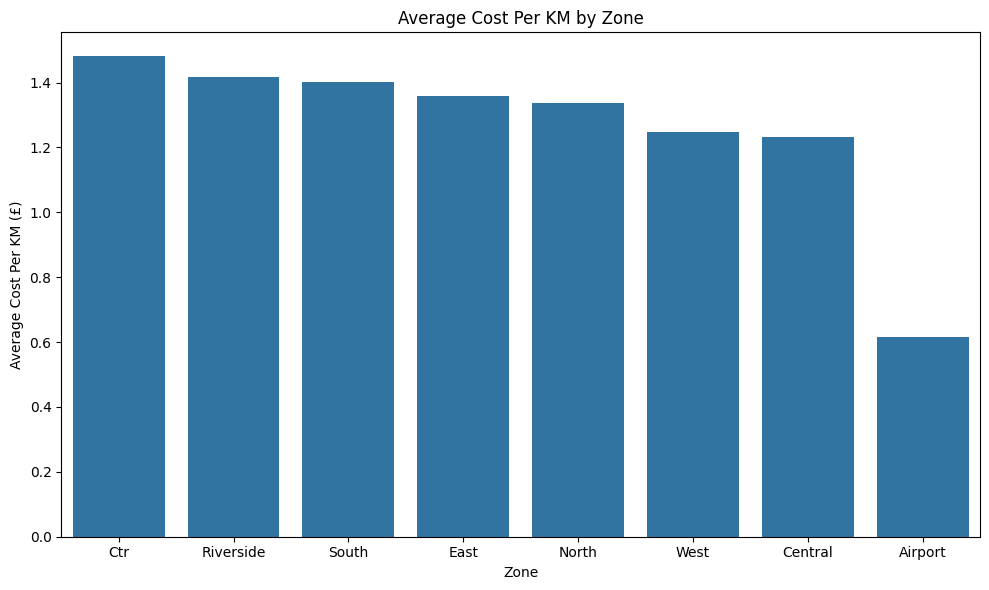

        zone  avg_cost_per_km
2        Ctr         1.480992
5  Riverside         1.417900
6      South         1.402091
3       East         1.359272
4      North         1.338075
7       West         1.248104
1    Central         1.232600
0    Airport         0.616088


In [28]:
# Cost per km by zone
zone_cost = deliveries.merge(orders[['order_id', 'pickup_zone']], on='order_id', how='left')
zone_cost = zone_cost.groupby('pickup_zone')['cost_per_km'].mean().reset_index()
zone_cost.columns = ['zone', 'avg_cost_per_km']
zone_cost = zone_cost.sort_values('avg_cost_per_km', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=zone_cost, x='zone', y='avg_cost_per_km')
plt.title('Average Cost Per KM by Zone')
plt.xlabel('Zone')
plt.ylabel('Average Cost Per KM (£)')
plt.tight_layout()
plt.show()

print(zone_cost)

Ctr, Riverside and South zones show the highest average cost
per km. Airport zone is significantly cheaper at £0.62 per km
compared to £1.48 in Ctr zone. This suggests urban central
routes are less cost efficient and may be contributing to
NorthStar's rising operational costs.

What This Chart Shows
It answers the business question:

"Which zones are the most expensive to operate in?"


Merges deliveries with orders to get the zone information
Calculates the average cost per km for each zone
Shows it as a bar chart to compare zones

This links to the finance director's concern about some routes being unprofitable.

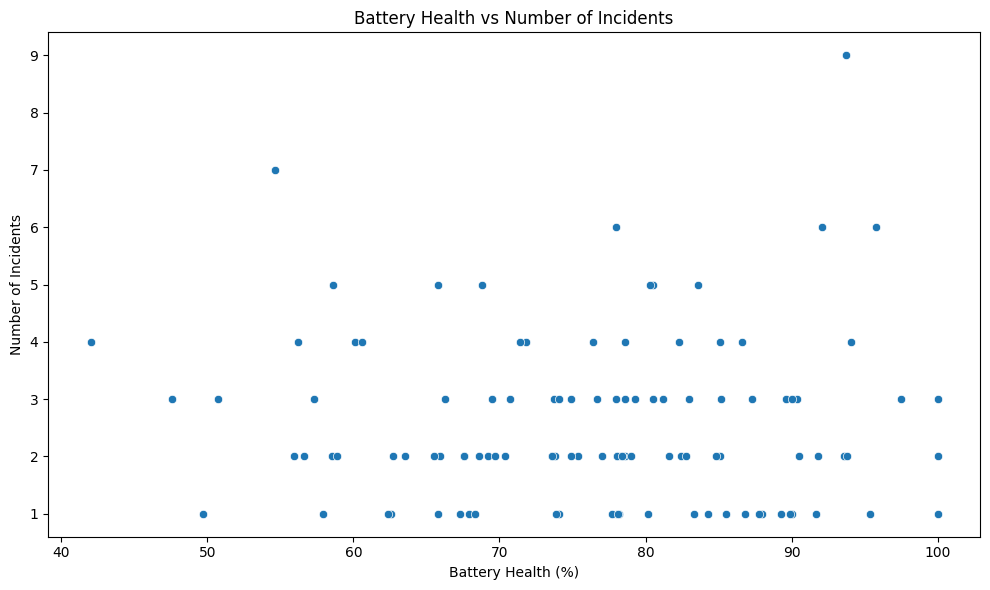

  vehicle_id  incident_count  battery_health
0       V001               4           71.80
1       V002               1           67.90
2       V003               1           91.70
3       V004               1           78.05
4       V005               5           58.60
5       V006               3           78.60
6       V007               2           68.60
7       V008               2           90.50
8       V009               5           68.80
9       V010               3           50.70


In [29]:
# Battery health vs incidents
vehicle_incidents = incidents.merge(deliveries[['delivery_id', 'vehicle_id']], on='delivery_id', how='left')
vehicle_incidents = vehicle_incidents.merge(vehicles[['vehicle_id', 'battery_health_pct']], on='vehicle_id', how='left')
incident_count = vehicle_incidents.groupby('vehicle_id').agg(
    incident_count=('incident_id', 'count'),
    battery_health=('battery_health_pct', 'mean')
).reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(data=incident_count, x='battery_health', y='incident_count')
plt.title('Battery Health vs Number of Incidents')
plt.xlabel('Battery Health (%)')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

print(incident_count.head(10))

Vehicles with lower battery health tend to show higher incident
counts. V005 and V009 have the most incidents at 5 each, with
V005 having only 58.6% battery health. This suggests NorthStar
should proactively flag vehicles below 60% battery health for
maintenance before incidents occur.

What This Chart Shows
It answers the business question:

"Do vehicles with lower battery health have more incidents?"


Merges incidents with deliveries to get the vehicle ID
Merges with vehicles to get battery health percentage
Counts how many incidents each vehicle had
Shows a scatter plot comparing battery health to incident count

This links to NorthStar's concern about vehicle maintenance issues being detected too late.

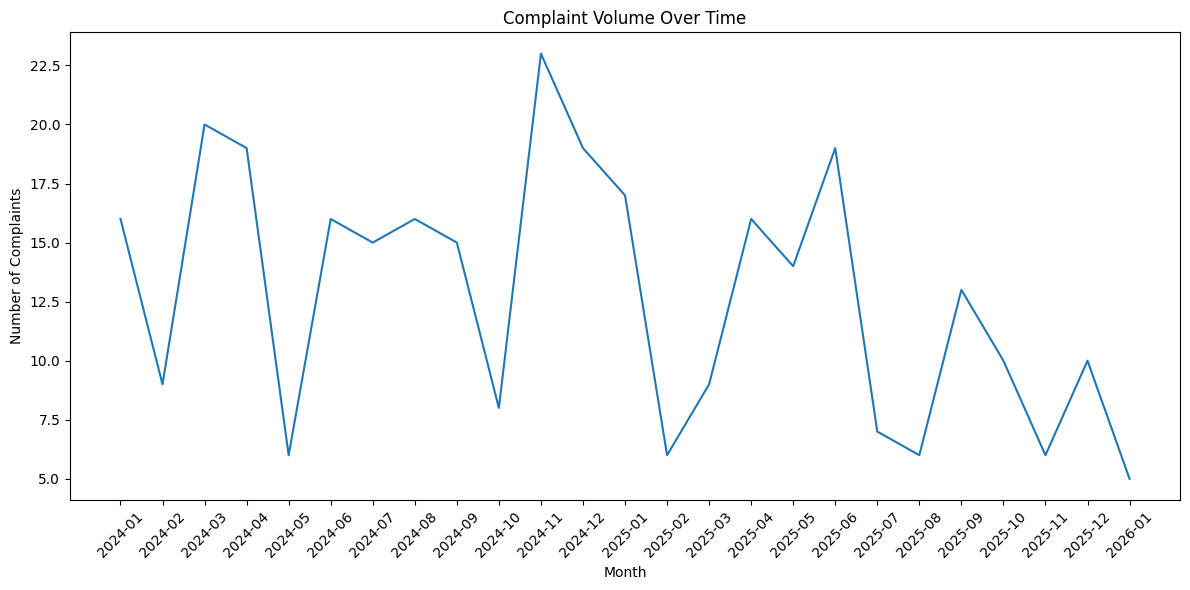

      month  complaint_count
0   2024-01               16
1   2024-02                9
2   2024-03               20
3   2024-04               19
4   2024-05                6
5   2024-06               16
6   2024-07               15
7   2024-08               16
8   2024-09               15
9   2024-10                8
10  2024-11               23
11  2024-12               19
12  2025-01               17
13  2025-02                6
14  2025-03                9
15  2025-04               16
16  2025-05               14
17  2025-06               19
18  2025-07                7
19  2025-08                6
20  2025-09               13
21  2025-10               10
22  2025-11                6
23  2025-12               10
24  2026-01                5


In [32]:
# Complaint volume over time
complaints['created_at'] = pd.to_datetime(complaints['created_at'])
complaint_trend = complaints.groupby(complaints['created_at'].dt.to_period('M')).size().reset_index()
complaint_trend.columns = ['month', 'complaint_count']
complaint_trend['month'] = complaint_trend['month'].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=complaint_trend, x='month', y='complaint_count')
plt.title('Complaint Volume Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(complaint_trend)

Complaint volume peaked in November 2024 at 23 complaints
and March 2024 at 20. There appears to be a general decline
into 2025 and 2026 however monthly spikes suggest recurring
operational problems. NorthStar should investigate what caused
the November 2024 peak specifically.

What This Chart Shows
It answers the business question:

"Is complaint volume increasing or decreasing over time?"


Groups complaints by month
Counts how many complaints were received each month
Shows it as a line chart to spot trends over time

This links to NorthStar's concern about increasing customer complaints.

In [33]:
# Check for orphaned records across files
orphan_deliveries = ~deliveries['order_id'].isin(orders['order_id'])
print(f"Deliveries with no matching order: {orphan_deliveries.sum()}")

orphan_complaints = ~complaints['order_id'].isin(orders['order_id'])
print(f"Complaints with no matching order: {orphan_complaints.sum()}")

orphan_incidents = ~incidents['delivery_id'].isin(deliveries['delivery_id'])
print(f"Incidents with no matching delivery: {orphan_incidents.sum()}")

Deliveries with no matching order: 0
Complaints with no matching order: 0
Incidents with no matching delivery: 0
